<a href="https://colab.research.google.com/github/diego-gutierrez10/diego-gutierrez10/blob/main/ProyectoFinal_EDyA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto final: Juego de la llave**

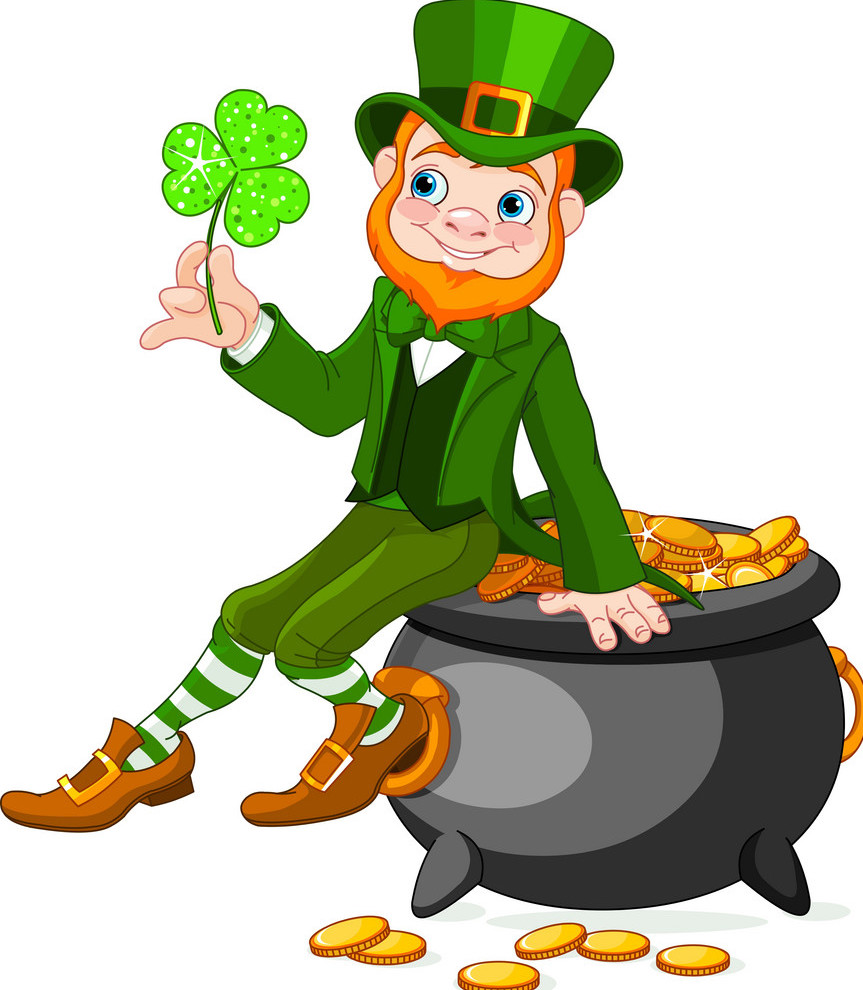

## Real Code

## **Desarrollo de funciones**

En esta sección se desarrollan las funciones necesarias para la operación del juego:

In [ ]:
import random # Importación de la librería Random

def fill_rand(llave): # Función que llena de 0 el grafo de la llave y solo a uno de ellos lo llena con un 1
  for i in llave:
    llave[i] = 0
  llave[random.choice(list(llave))] = 1

def pista():  # Función que devuelve un solo amigo de los amigos directos (en 1er grado) de la persona que tiene la llave
  for i in llave:
    if llave[i] == 1:
      return random.choice(list(amigos[i]))

def grado(guess): # Función que retorna la distancia mínima (grado) entre la persona del guess del usuario y la que tiene la llave
  for i in llave:
    if llave[i] == 1:
      v = len(list(amigos));
      source = adj_aux[guess]
      dest = adj_aux[i]
      return printShortestDistance(adj, source, dest, v)  # LLamado a una función externa que permite obtener la distancia entre 2 nodos puntuales

def evaluar(persona): # Función booleana que evalia si el guess dado por el usuario es el que tiene la llave o no
  if llave[persona] == 1:
    return True
  else:
    return False

Función externa "printShortestDistance()", desarrollada por el usuario rutvik_56 del sitio [GeeksForGeeks](https://www.geeksforgeeks.org/shortest-path-unweighted-graph/). Que permite obtener la distancia más corta entre 2 nodos de un grafo, mediante la tranformación de un grafo a una "lista de adyacencia".

In [ ]:
# Python3 code for printing shortest path between
# two vertices of unweighted graph

# utility function to form edge between two vertices
# source and dest
def add_edge(adj, src, dest):

	adj[src].append(dest);
	adj[dest].append(src);

# a modified version of BFS that stores predecessor
# of each vertex in array p
# and its distance from source in array d
def BFS(adj, src, dest, v, pred, dist):

	# a queue to maintain queue of vertices whose
	# adjacency list is to be scanned as per normal
	# DFS algorithm
	queue = []

	# boolean array visited[] which stores the
	# information whether ith vertex is reached
	# at least once in the Breadth first search
	visited = [False for i in range(v)];

	# initially all vertices are unvisited
	# so v[i] for all i is false
	# and as no path is yet constructed
	# dist[i] for all i set to infinity
	for i in range(v):

		dist[i] = 1000000
		pred[i] = -1;

	# now source is first to be visited and
	# distance from source to itself should be 0
	visited[src] = True;
	dist[src] = 0;
	queue.append(src);

	# standard BFS algorithm
	while (len(queue) != 0):
		u = queue[0];
		queue.pop(0);
		for i in range(len(adj[u])):

			if (visited[adj[u][i]] == False):
				visited[adj[u][i]] = True;
				dist[adj[u][i]] = dist[u] + 1;
				pred[adj[u][i]] = u;
				queue.append(adj[u][i]);

				# We stop BFS when we find
				# destination.
				if (adj[u][i] == dest):
					return True;

	return False;

# utility function to print the shortest distance
# between source vertex and destination vertex
def printShortestDistance(adj, s, dest, v):

	# predecessor[i] array stores predecessor of
	# i and distance array stores distance of i
	# from s
	pred=[0 for i in range(v)]
	dist=[0 for i in range(v)];

	if (BFS(adj, s, dest, v, pred, dist) == False):
		print("Given source and destination are not connected")

	# vector path stores the shortest path
	path = []
	crawl = dest;
	path.append(crawl);

	while (pred[crawl] != -1):
		path.append(pred[crawl]);
		crawl = pred[crawl];


	# distance from source is in distance array
	return (str(dist[dest]))

# This code is contributed by rutvik_56

## **Implementación de grafos**

A continuación se crean y se llenan los grafos necesarios para el funcionamiento del juego.

In [ ]:
amigos = {} # El grafo amigos permite mapear quien es amigo de quien, mediante una estructura tipo Dict()

amigos["diego"] = ["emilio", "andres", "jesus", "raul"]
amigos["emilio"] = ["diego", "keymi", "andres"]
amigos["keymi"] = ["emilio", "francisco"]
amigos["francisco"] = ["keymi"]
amigos["andres"] = ["diego", "enrique", "emilio", "jesus"]
amigos["jesus"] = ["samuel", "enrique", "diego", "angel", "andres"]
amigos["enrique"] = ["jesus", "andres", "samuel"]
amigos["samuel"] = ["jesus", "enrique", "angel"]
amigos["angel"] = ["samuel", "jesus", "cesar"]
amigos["raul"] = ["max", "sean", "diego"]
amigos["max"] = ["raul", "sean"]
amigos["sean"] = ["raul", "max"]
amigos["cesar"] = ["angel"]

llave = {}  # El grafo llave permite determinar quien tendrá la llave

llave["diego"] = 0
llave["emilio"] = 0
llave["keymi"] = 0
llave["francisco"] = 0
llave["andres"] = 0
llave["jesus"] = 0
llave["enrique"] = 0
llave["samuel"] = 0
llave["angel"] = 0
llave["raul"] = 0
llave["max"] = 0
llave["sean"] = 0
llave["cesar"] = 0

Grafos auxiliares de la función externa:

In [ ]:
adj_aux = {}  # Este grafo solo es auxiliar, mapea cada nombre con un identificador numérico para ser utilizado en la función "add_edge", ya que solo funciona con números

adj_aux["diego"] = 0
adj_aux["enrique"] = 6
adj_aux["jesus"] = 2
adj_aux["samuel"] = 7
adj_aux["andres"] = 3
adj_aux["emilio"] = 1
adj_aux["keymi"] = 4
adj_aux["francisco"] = 5
adj_aux["angel"] = 8
adj_aux["cesar"] = 9
adj_aux["raul"] = 10
adj_aux["sean"] = 11
adj_aux["max"] = 12

v = len(list(amigos));  # Variable V con la longitud del grafo amigos, que nos permite inicializar la lista de adyacencia

adj = [[] for i in range(v)]; # Creación de la lista de adyacencia e inicialización de n campos vacios según la longitud del grafo principal

add_edge(adj, 0, 1);  # LLamado de la función externa "add_edge" que permite añadir cada elemento a la lista de adyacencia
add_edge(adj, 0, 2);
add_edge(adj, 0, 3);
add_edge(adj, 0, 10);
add_edge(adj, 10, 12);
add_edge(adj, 10, 11);
add_edge(adj, 11, 12);
add_edge(adj, 1, 4);
add_edge(adj, 1, 3);
add_edge(adj, 4, 5);
add_edge(adj, 2, 3);
add_edge(adj, 3, 6);
add_edge(adj, 2, 6);
add_edge(adj, 6, 7);
add_edge(adj, 2, 7);
add_edge(adj, 2, 8);
add_edge(adj, 8, 7);
add_edge(adj, 8, 9);

## **Main**

Desarrollo del Main, en donde se encuentra la dinámica principal del juego y el llamado de cada función.

In [ ]:
fill_rand(llave)  # Se inicializan con 0 los nodos del grafo "llave" y aleatoriamente con 1 a uno de ellos, simbolizando que tiene la llave

print("¡Bienvenido al juego de la llave!\n")  # Mensaje de Bievenida

print("El profe Pellegrin ha escondido la llave a su caldero lleno de monedas de oro 🪙👑 entre los alumnos de EDyA, y tienes que adivinar quién lo tiene...\n\nSolo tienes 3 intentos, y después de cada uno te diré que tan cerca estás. ¡Suerte!\n")  # Mensaje de bienvenida 2

for i in range(3):  # Ciclo For que otorga 3 oportunidades de adivinar quien tiene la llave

  if i == 2:  # Verificación si ya hizo dos intentos de adivinanza el usuario
    print("Pista: es amigo de " + pista() + " 👀")  # En caso de ser asi, se le da una pista al usuario de un amigo directo de quien tiene la llave mediante la función "pista()"

  guess = input("¿Quién crees que tenga la llave? 🤔 ") # Impresión del mensaje y captura del nombre de la persona que el usuario cree que tiene la llave

  if evaluar(guess) == True:  # If para cuando el "guess" del usuario es exitoso, es decir, que si adivino quien tiene la llave
    print ("\n¡Ganaste! 🤑 " + guess + " tenia el pozo de oro. 🌟") # Mensaje de éxito
    break # Finalización del programa

  else: # Else para cuando el usuario no adivina quien tiene la llave
    print ("\nLo siento " + guess + " no tiene el pozo de oro. 😞") # Mensaje de fracaso
    distancia = grado(guess)  # Variable "Distancia" que guarda el valor devuelto por la función "grado()" que da la distancia más corta entre el guess del usuario y la persona con la llave

    if int(distancia) in range(4, 7): # If para evaluar que tan cerca estuvo el usuario de adivinar, caso para cuando estuvo en grado 5 o 6
      print("¡Lejos 🥶! Estas en grado " + distancia + " del grafo con quien tiene la llave\n")  # Impresión del mensaje que estuvo lejos de adivinar

    elif int(distancia) in range(2, 4): #Elif para evaluar que tan cerca estuvo el usuario de adivinar, caso para cuando estuvo en grado 3 o 4
      print("Masomenos 🫤, estas en grado " + distancia + " del grafo con quien tiene la llave\n")  # Impresión del mensaje que estuvo masomenos cerca de adivinar

    elif int(distancia) in range(1, 2): #Elif para evaluar que tan cerca estuvo el usuario de adivinar, caso para cuando estuvo en grado 1 o 2
      print("¡Muy cerca 🥵! Estas en grado " + distancia + " del grafo con quien tiene la llave\n") # Impresión del mensaje que estuvo cerca de adivinar


¡Bienvenido al juego de la llave!

El profe Pellegrin ha escondido la llave a su caldero lleno de monedas de oro 🪙👑 entre los alumnos de EDyA, y tienes que adivinar quién lo tiene...

Solo tienes 3 intentos, y después de cada uno te diré que tan cerca estás. ¡Suerte!

¿Quién crees que tenga la llave? 🤔 emilio

Lo siento emilio no tiene el pozo de oro. 😞
¡Muy cerca 🥵! Estas en grado 1 del grafo con quien tiene la llave

¿Quién crees que tenga la llave? 🤔 keymi

¡Ganaste! 🤑 keymi tenia el pozo de oro. 🌟


Representación visual del grafo amigos:

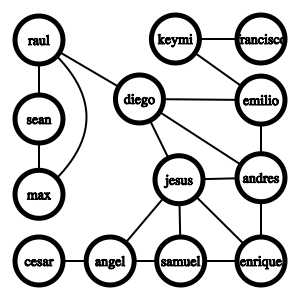

## **Gracias por utilizar este Notebook, espero que haya sido de su agrado 😃**



---


## **Diego Alejandro Gutiérrez Rios**
**diego.gutierrez10@uabc.edu.mx**

TODOS LOS DERECHOS RESEVADOS ©
